## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import warnings
import re
import matplotlib.image as mpimg
import os
import csv
import glob

from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")

os.makedirs("ims", exist_ok=True)
# os.makedirs("ims/current", exist_ok=True)
os.makedirs("ims/all", exist_ok=True)

os.makedirs("all_data", exist_ok=True)

os.makedirs("all_data/inputs", exist_ok=True)

os.makedirs("all_data/current_energy", exist_ok=True)
os.makedirs("all_data/current_energy/data", exist_ok=True)
os.makedirs("all_data/current_energy/ims", exist_ok=True)
os.makedirs("all_data/current_energy/ims/all", exist_ok=True)
os.makedirs("all_data/current_energy/ims/energy_current", exist_ok=True)

os.makedirs("all_data/current_energy/ims/all/png", exist_ok=True)
os.makedirs("all_data/current_energy/ims/all/pdf", exist_ok=True)

os.makedirs("all_data/current_energy/ims/energy_current/png", exist_ok=True)
os.makedirs("all_data/current_energy/ims/energy_current/pdf", exist_ok=True)



os.makedirs("all_data/hhg", exist_ok=True)
os.makedirs("all_data/nonlinear", exist_ok=True)

os.makedirs("all_data/drude", exist_ok=True)
os.makedirs("all_data/drude/data", exist_ok=True)
os.makedirs("all_data/drude/data/current", exist_ok=True)
os.makedirs("all_data/drude/data/m", exist_ok=True)
os.makedirs("all_data/drude/data/abc", exist_ok=True)
os.makedirs("all_data/drude/data/tau", exist_ok=True)
os.makedirs("all_data/drude/data/n_ex", exist_ok=True)
os.makedirs("all_data/drude/ims", exist_ok=True)

os.makedirs("all_data/fid", exist_ok=True)
os.makedirs("all_data/fid/data", exist_ok=True)
os.makedirs("all_data/fid/ims", exist_ok=True)


volume = 160.1 # для Si в A^3

# m0_cut_1 = 10500  # 21 fs: for exp fit
# m0_cut_2 = 6250   # 12.5 fs: for full drude fit (needs to be adjusted in accordance to z_pump energy)
# # 3749 (7.5 fms), 5999 (12 fms)

# m0_cut_3 = 5250 # 10.5 fs: start of integration for Δk analysis. half of probe pulse duration

# In[116]:


plt.rcParams['font.family'] = 'serif'
import matplotlib
# matplotlib.use('Agg')
# print(matplotlib.get_backend())


## plot func

In [38]:
def plot_nonlinear_response_v4(folder, ax, j):


    t_probe, t_pump = get_pulse_durations(folder)

    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration

    m0_cut_2 = m0_cut_3+500 # adjustable

    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse

    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )


    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']


    t = data_both['time_fs']


    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']

    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']

    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']


    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']


    # 1:Time[fs] 2:Ac_ext_x[fs*V/Angstrom] 3:Ac_ext_y[fs*V/Angstrom] 4:Ac_ext_z[fs*V/Angstrom]
    #5:E_ext_x[V/Angstrom] 6:E_ext_y[V/Angstrom] 7:E_ext_z[V/Angstrom] 8:Ac_tot_x[fs*V/Angstrom]
    # 9:Ac_tot_y[fs*V/Angstrom] 10:Ac_tot_z[fs*V/Angstrom] 11:E_tot_x[V/Angstrom]
    # 12:E_tot_y[V/Angstrom] 13:E_tot_z[V/Angstrom]  14:Jm_x[1/fs*Angstrom^2] 15:Jm_y[1/fs*Angstrom^2] 16:Jm_z[1/fs*Angstrom^2]


    # Построим графики
    plt.figure(figsize=(10, 12.5))

    # Общий заголовок для всей фигуры
    plt.suptitle(' '.join(re.split('[/_]', folder)), fontsize=14, y=0.99)

    # Первый график: внешнее поле по z
    plt.subplot(5, 2, 1)
    plt.plot(t, El_f_pump_z, label='E_ext_z', color='#2CD311')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [V/Å]')
    plt.title('Pump external electric field z')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()

    # Второй график: внешнее поле по x
    plt.subplot(5, 2, 2)
    plt.plot(t, El_f_probe_x, label='E_ext_z', color='c')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [V/Å]')
    plt.title('Probe external electric field x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()

    # # Четвертый график: суммарный ток по z
    # plt.subplot(5, 2, 4)
    # plt.plot(t, Jm_pump_z, color='magenta')
    # plt.xlabel('Time [fs]')
    # plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    # plt.title('Matter current density along z, only pump')
    # plt.grid(True)

    # plt.tight_layout()





    
    t_array_cut = np.array(t[m0_cut_4:])[::50]
    j_exp = np.array(Jm_pump_z[m0_cut_4:])[::50]
    # (dummy_t, j0, j_final, tau)
    p0 = [0.02, 0, 6.65]   # начальные приближения (n, tau)
    popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0)
    j0, j_final, tau_pump= popt
    j_fit = drude_exp_fit_v2_pump(0, j0, j_final, tau_pump)

    # ratio = j_final/max(delta_Jm_x)

    # Разностный ток по x
    plt.subplot(5, 2, 4)
    plt.plot(t, Jm_pump_z, color='m')
    if tau_pump<30:
        plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau_pump:.2f}\ \mathrm{{fs}}$", color='r')
    else: plt.plot(t_array_cut, j_fit, '--', color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Δ matter current density along x')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()



    
    



    product_both_z = El_f_pump_z * Jm_both_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_z = np.cumsum(product_both_z * dt)

    product_both_x = El_f_probe_x * Jm_both_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_x = np.cumsum(product_both_x * dt)

    product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_x = np.cumsum(product_delta_x * dt)



    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 3)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_both_z, label='ΔE = E_total - E_initial', color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Energy transfer per unit cell along z')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()



    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 5)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_both_x, label='ΔE = E_total - E_initial', color='blue')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Energy transfer per unit cell along x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()


    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 6)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_delta_x, label='ΔE = E_total - E_initial', color='black')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Δ energy transfer per unit cell along x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()



    # Суммарный ток по x
    plt.subplot(5, 2, 7)
    plt.plot(t, Jm_both_x, color='#DC143C')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Full matter current density along x')
    plt.grid(True)
    plt.tight_layout()
    
    
    
    
    delta_Jm_x = Jm_both_x - Jm_pump_x - Jm_probe_x

    
    t_array_cut = np.array(t[m0_cut_1:])[::50]
    j_exp = np.array(delta_Jm_x[m0_cut_1:])[::50]
    # (dummy_t, j0, j_final, tau)
    p0 = [0.03, 0.01, 6.65]   # начальные приближения (n, tau)
    popt, pcov = curve_fit(drude_current_v1, t_array_cut, j_exp, p0=p0)
    j0, j_final, tau= popt
    j_fit = drude_current_v1(0, j0, j_final, tau)

    ratio = j_final/max(delta_Jm_x)

    # Разностный ток по x
    plt.subplot(5, 2, 8)
    plt.plot(t, (Jm_both_x - Jm_pump_x - Jm_probe_x), color='#00FF7F')
    plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau:.2f}\ \mathrm{{fs}} \quad j_{{\rm final}} : j_{{\rm max}} = {ratio:.2f}$", color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Δ matter current density along x')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()




    # Суммарный ток по y
    plt.subplot(5, 2, 9)
    plt.plot(t, Jm_both_y, color='#00BFFF')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Full matter current density along y')
    plt.grid(True)
    plt.tight_layout()


    # Разностный ток по y
    plt.subplot(5, 2, 10)
    plt.plot(t, (Jm_both_y - Jm_pump_y - Jm_probe_y), color='#FF007F')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Δ matter current density along y')
    plt.grid(True)
    plt.tight_layout()





    # lr_data = pd.read_csv(
    #     folder + '/lr_response.data',
    #     comment='#',
    #     delim_whitespace=True,
    #     header=None
    # )

    # lr_data.columns = [
    #     'Energy',        # 1
    #     'Re_sigma_x',    # 2
    #     'Re_sigma_y',    # 3
    #     'Re_sigma_z',    # 4
    #     'Im_sigma_x',    # 5
    #     'Im_sigma_y',    # 6
    #     'Im_sigma_z',    # 7
    #     'Re_eps_x',      # 8
    #     'Re_eps_y',      # 9
    #     'Re_eps_z',      # 10
    #     'Im_eps_x',      # 11
    #     'Im_eps_y',      # 12
    #     'Im_eps_z',      # 13
    # ]


    # # Построение графика изменения энергии во времени
    # plt.subplot(5, 2, 9)
    # plt.plot(lr_data['Energy'][100:], lr_data['Im_eps_z'][100:], label='Im(ε)', color='#00BFFF')
    # plt.xlabel('E [eV]')
    # plt.ylabel('Im(ε)')
    # plt.title('Absorption')
    # plt.grid(True)
    # #plt.legend()
    # plt.tight_layout()

    # # Построение графика изменения энергии во времени
    # plt.subplot(5, 2, 10)
    # plt.plot(lr_data['Energy'][100:], lr_data['Re_eps_z'][100:], label='Re(ε)', color='#FF007F')
    # plt.xlabel('E [eV]')
    # plt.ylabel('Re(ε)')
    # plt.title('Dispersion')
    # plt.grid(True)
    # #plt.legend()
    # plt.tight_layout()
    # # plt.show()

    # plt.savefig("ims/all/" + folder + ".pdf")
    plt.savefig("ims/all/" + str(j)+ '_' + folder + ".png", dpi=200)

    dt = np.diff(t, prepend=t[0])

    arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
    a_start = arr[m0_cut_2-m0_cut_3]
    a_fin = arr[-1]

    return tau, a_start, a_fin


# In[ ]:


## extract

In [39]:
def drude_current_v1(dummy_t, j0, j_final, tau):

    # tau = 6.65
    dt = 0.002

    t_probe, t_pump = get_pulse_durations(folder)
    m0_cut_1 = int(500*t_probe)

    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

        
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_1:])         # сетка времени
    # E_array = -np.array(El_f_probe_x[m0_cut_1:]) 
    
    
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + dt * (-(j_euler[k]-j_final)/tau)


    return j_euler[::50]

In [40]:
def drude_exp_fit_v2_pump(dummy_t, j0, j_final, tau):


    t_probe, t_pump = get_pulse_durations(folder)
    m0_cut_4 = int(500*(t_probe+t_pump)/2) 
    
    # tau = 6.65
    dt = 0.002

    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

        
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_4:])         # сетка времени
    # E_array = -np.array(El_f_probe_x[m0_cut_1:]) 
    
    
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + dt * (-(j_euler[k]-j_final)/tau)


    return j_euler[::50]

In [41]:
def extract_c_num(s):
    start = s.index('c') + 1
    end = s.index('_', start)
    return int(s[start:end])

def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_k_num(s):
    start = s.index('_k') + 2
    end = s.index('_', start)
    return int(s[start:end])

def extract_a_num(s):
    start = s.index('_a') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_r_num(s):
    start = s.index('_r') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_i_num(s):
    start = s.index('_i') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    if match:
        return match.group(1)

In [42]:
def get_n_excited_electrons(folder):

    output_probe = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/probe_pulse_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_probe = nelec[-1]

    output_pump = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/pump_pulse_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_pump = nelec[-1]


    output_both = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/both_pulses_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_both = nelec[-1]


    
    gs_file = glob.glob(folder + '/Si_gs*')

    with open(gs_file[0], 'r') as file:
        lines = file.readlines()
    
    for line in lines:
        if 'al(1:3)' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            factor = nums[0]*nums[1]*nums[2]

    return output_both/factor, output_pump/factor, output_probe/factor

In [43]:
def get_pulse_durations(folder):

    pulses_file = glob.glob(folder + '/Si_rt_both*')
    
    with open(pulses_file[0], 'r') as file:
            lines = file.readlines()
        
    for line in lines:
        if 'tw1' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            t_probe = nums[0]
    
    for line in lines:
        if 'tw2' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            t_pump = nums[0]

    return t_probe, t_pump

## Plots

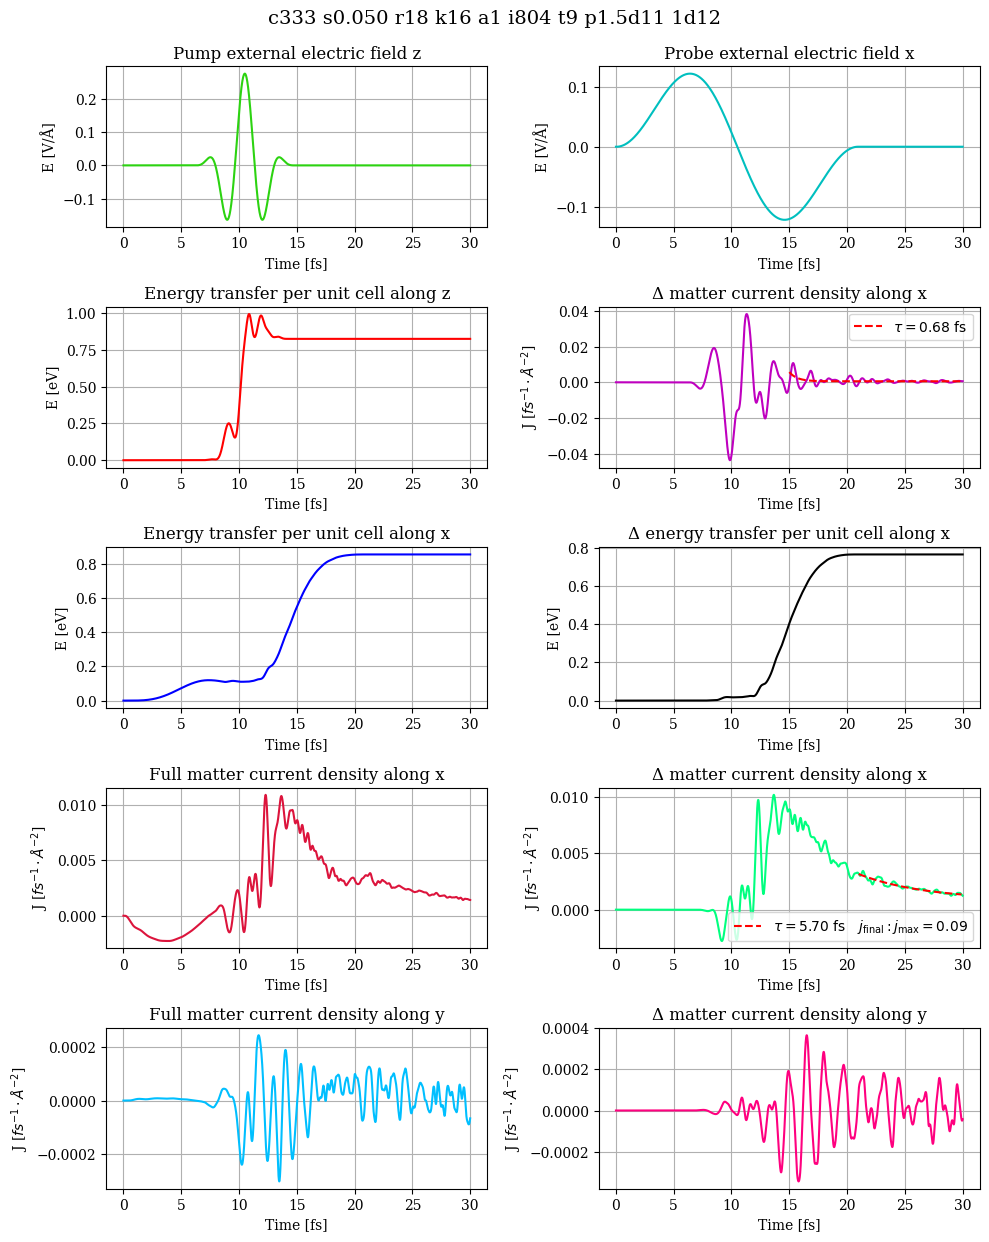

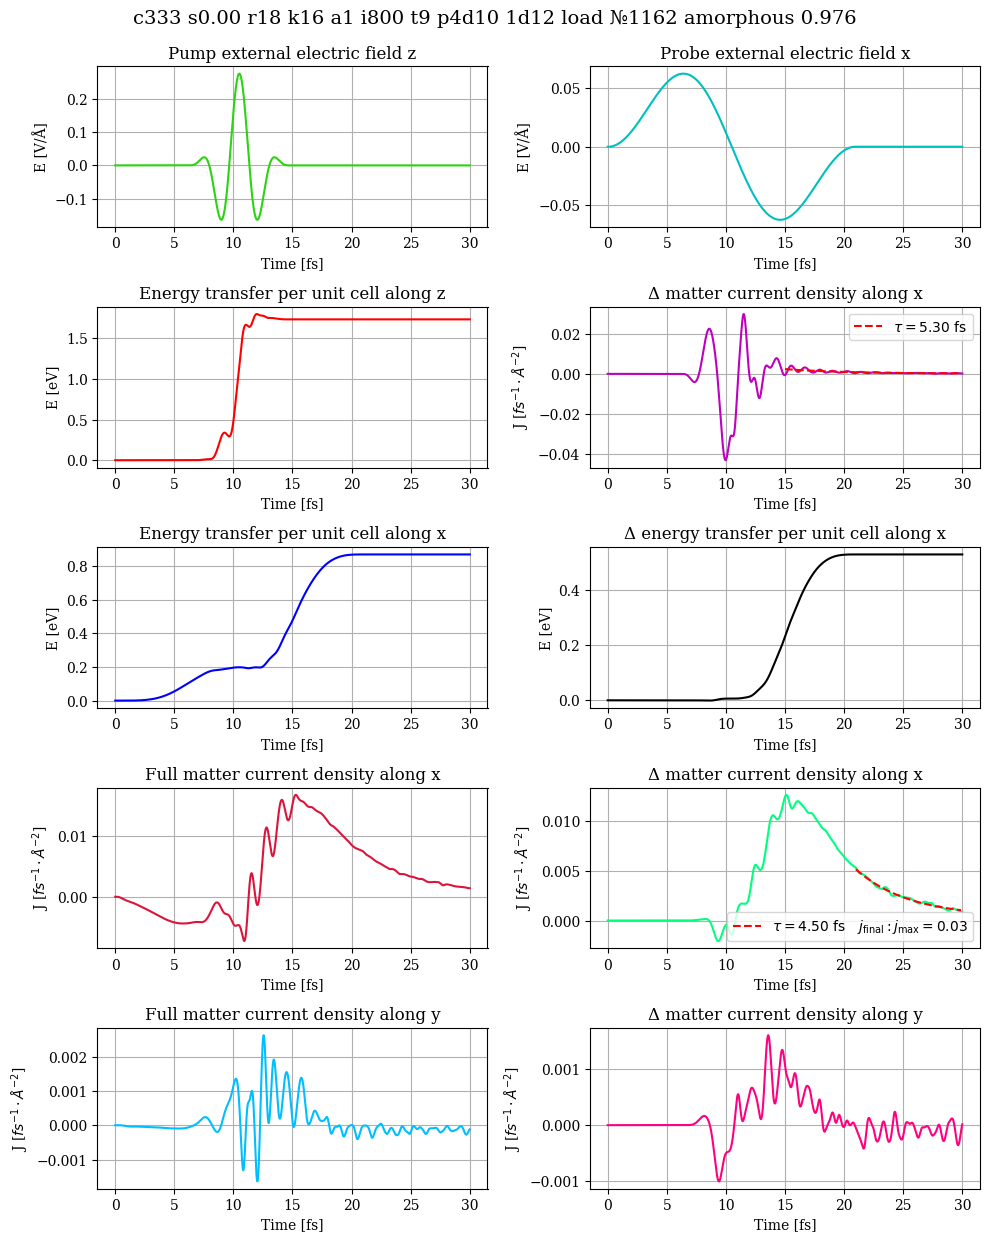

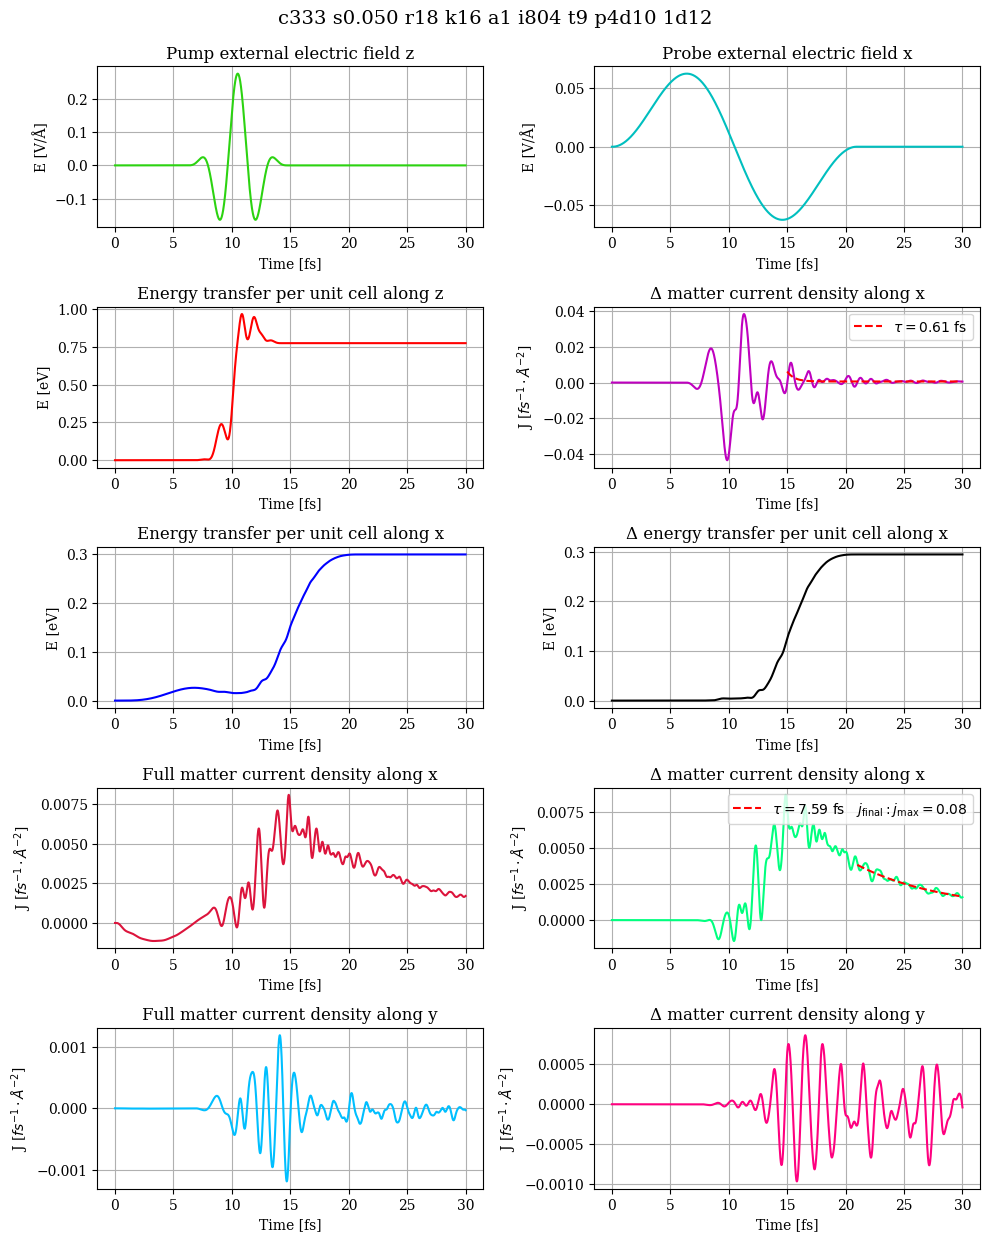

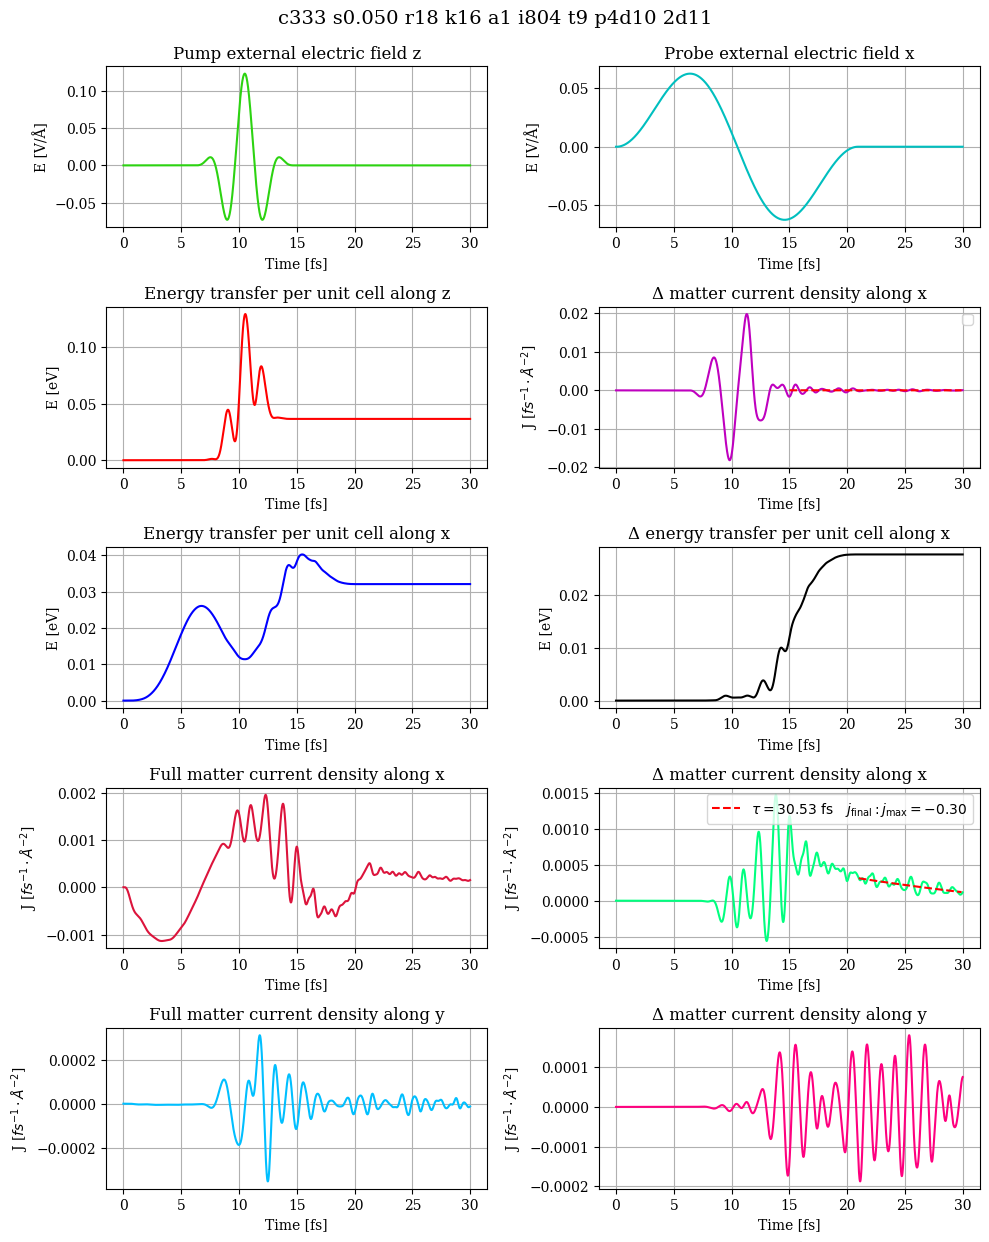

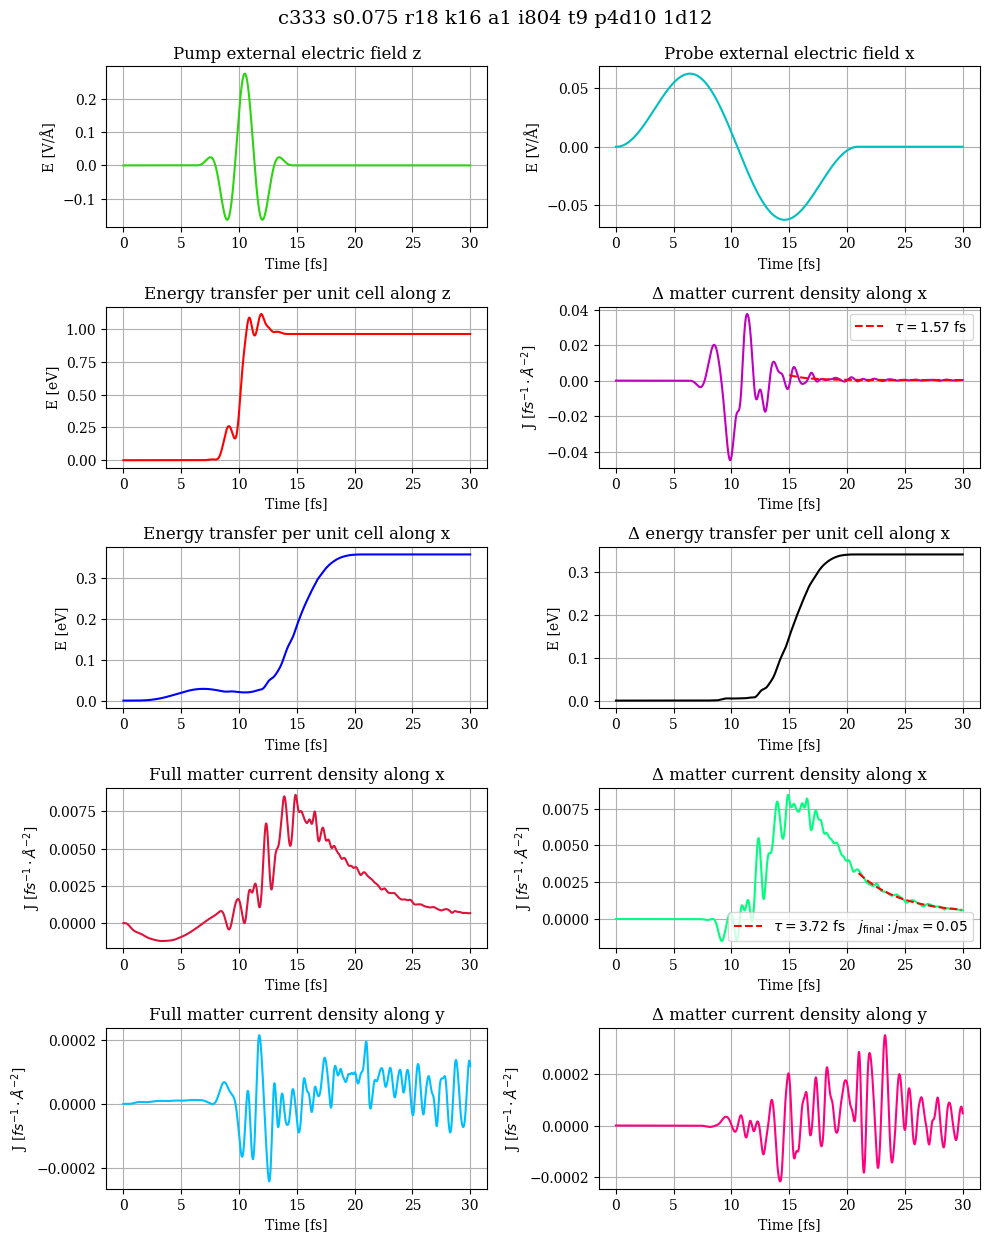

In [44]:
ax = 'z'

folders = [name for name in os.listdir('.') if os.path.isdir(os.path.join('.', name))]

# folders = [f for f in folders if f.startswith('c')]
folders = [f for f in folders 
           if f.startswith('c') 
           and os.path.isfile(os.path.join(f, 'probe_pulse_rt.data')) 
           and not os.path.isdir(os.path.join(f, 'restart'))]


# print(folders)


# Сортировка: сначала по c, потом по s, потом по k
sorted_folders = sorted(folders, key=lambda s: (extract_p(s), extract_c_num(s), extract_r_num(s), extract_s_num(s), extract_k_num(s), extract_a_num(s), extract_i_num(s)))


# In[74]:

alphas_start = []
alphas_final = []
taus = []

j=0
for folder in sorted_folders:
    j=j+1
    
    tau, a_start, a_fin = plot_nonlinear_response_v4(folder, ax, j)
    alphas_start.append(a_start)
    alphas_final.append(a_fin)
    taus.append(tau)


# In[ ]:

## draft

In [7]:
def effecive_mass_model(alpha, a, b, c):
    return 1/(a**2 * alpha**4 + 0*alpha + c)

In [8]:
def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    t = data_both['time_fs']
    El_f_probe_x = data_both['E_ext_x']
    
    
    step_dt = 0.002
    
    m0_cut_2 = 6250
    
    dt = np.diff(t, prepend=t[0])
    
    
    alpha_E_t = np.cumsum(-2.64*El_f_probe_x[5250:]*dt[5250:])
    fit_alpha_E_t = alpha_E_t[1000:]
    
    alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_2:])         # сетка времени
    E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
    return j_euler[::1]

In [10]:
sorted_folders

['c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12',
 'c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976',
 'c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12',
 'c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11',
 'c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12']

In [11]:
new_taus

[np.float64(4.372685961758836),
 np.float64(4.581966248281581),
 np.float64(6.310594856305089),
 np.float64(2.0448358195611647),
 np.float64(4.317132248732618)]

In [12]:
get_n_excited_electrons(sorted_folders[0])[0]

np.float64(0.0011414111146725592)

In [13]:
sorted_folders

['c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12',
 'c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976',
 'c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12',
 'c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11',
 'c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12']

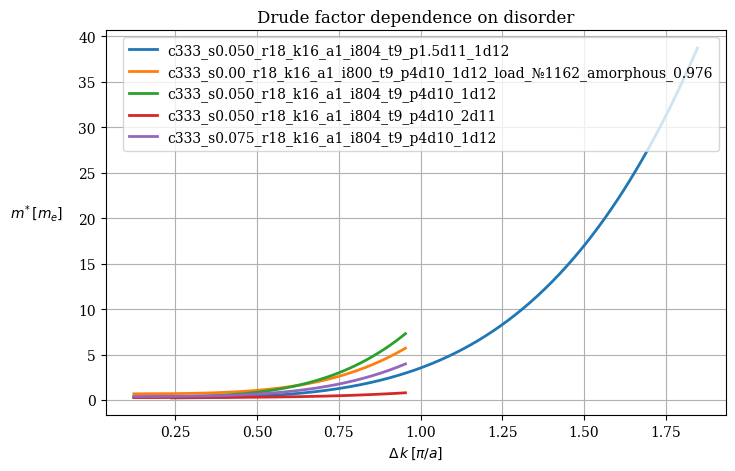

In [17]:
plt.figure(figsize=(8,5))
plt.title("Drude factor dependence on disorder")

plot_part=1
num_folder=0
for (a0, b0, c0) in arr_abc:
    num_folder+=1
    if num_folder!=0:
        plt.plot(np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500), [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500)], label=sorted_folders[num_folder-1], linewidth=2)

plt.grid()
plt.legend()
plt.xlabel(r'$\Delta \, k \, [\pi/a]$')
# plt.ylabel(r'$\dfrac{m$^*$}{n}$ [a.u.]')
# plt.ylabel(r'$\dfrac{m}{n}\, [a.u.]$', rotation=0,  labelpad=30)
plt.ylabel(r'$m^{*}\, [m_e]$', rotation=0,  labelpad=30)
plt.show()

# plt.savefig("drude_mass_adj/" + "Mass_Dependence_on_disorder" + ".png", dpi=200, bbox_inches='tight')

In [15]:
1+1

2

In [16]:
alphas_final

[np.float64(1.847325412368498),
 np.float64(0.9539547409505257),
 np.float64(0.9539547409505257),
 np.float64(0.9539547409505257),
 np.float64(0.9539547409505257)]

## draft FID

12.842452649904443 21340.422575086282 11.251991220526765


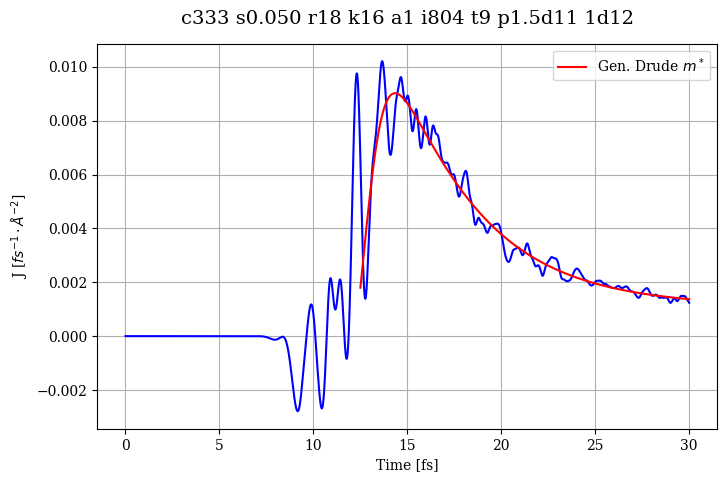

In [18]:
new_taus = []
new_j_finals = []
arr_abc = []

    
folder = sorted_folders[0]

# Загрузка данных, пропуская строки с комментариями (начинаются с #)
data_both = pd.read_csv(
    folder + '/both_pulses_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)


data_probe = pd.read_csv(
    folder + '/probe_pulse_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)


data_pump = pd.read_csv(
    folder + '/pump_pulse_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)


# Назначим читаемые имена колонкам
data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']

data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']

data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']


t = data_both['time_fs']


Jm_both_z  =  data_both['Jm_z']

Jm_both_x  =  data_both['Jm_x']
Jm_pump_x  =  data_pump['Jm_x']
Jm_probe_x =  data_probe['Jm_x']

Jm_both_y  =  data_both['Jm_y']
Jm_pump_y  =  data_pump['Jm_y']
Jm_probe_y =  data_probe['Jm_y']


El_f_pump_z = data_both['E_ext_z']
El_f_probe_x = data_both['E_ext_x']


# fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)


fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)



delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x

# t_array_cut = np.array(t[m0_cut_2:])[::50]
# j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
# # (dummy_t, j0, fit_alpha, j_final)
# p0 = [0.03, 0.2]   # начальные приближения (n, tau)
# # print(len(t_array_cut), len(j_exp))
# popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
# j0, fit_alpha = popt
# j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)

plt.figure(figsize=(8,5))
plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
plt.plot(t, delta_Jm_x, color='b')
# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
plt.xlabel("Time [fs]")
plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]")


t_array_cut = np.array(t[m0_cut_2:])[::1]
j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
# (dummy_t, j0, fit_alpha, j_final)
p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
# print(len(t_array_cut), len(j_exp))
popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
[-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
))
j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)

new_taus.append(fit_tau_val)
new_j_finals.append(fit_j_fin_val)

plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
plt.legend()
plt.grid()
arr_abc.append((a, b, c))
print(a, b, c)

In [19]:
delta_Jm_x

0        4.200718e-11
1        5.310121e-11
2        6.039424e-11
3        6.796618e-11
4        7.814170e-11
             ...     
14995    1.243770e-03
14996    1.241994e-03
14997    1.240248e-03
14998    1.238533e-03
14999    1.236848e-03
Name: Jm_x, Length: 15000, dtype: float64

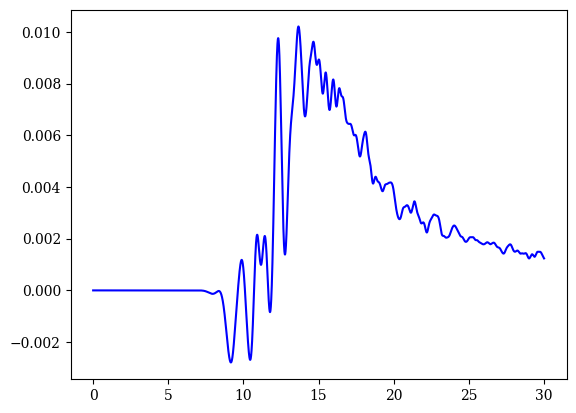

In [20]:
plt.plot(t, delta_Jm_x, color='b')

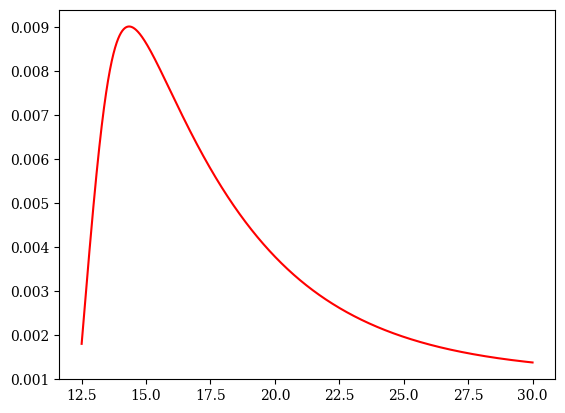

In [21]:
plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')

In [22]:
t_array_cut

array([12.502, 12.504, 12.506, ..., 29.996, 29.998, 30.   ], shape=(8750,))

In [23]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

def build_nonFID_component_with_zero_plateau(
    t,                 # pd.Series или np.ndarray, полная сетка времени
    t_array_cut,       # np.ndarray, время для друде-фита (начиная ~12.5 fs)
    j_fit,             # np.ndarray, значения друде-фита
    t_zero_end=9.0,    # fs: до этого времени nonFID принудительно 0
    halfmax=0.5,       # t1 = первая точка, где j_fit >= halfmax*max
):
    t_full = np.asarray(t, dtype=float)
    t_cut = np.asarray(t_array_cut, dtype=float)
    j_cut = np.asarray(j_fit, dtype=float)

    if t_cut.shape != j_cut.shape:
        raise ValueError("t_array_cut и j_fit должны быть одинаковой длины.")

    # сортировка на всякий случай
    order = np.argsort(t_cut)
    t_cut = t_cut[order]
    j_cut = j_cut[order]

    # --- t1 по halfmax ---
    jmax = np.nanmax(j_cut)
    if not np.isfinite(jmax) or jmax == 0:
        raise ValueError("j_fit выглядит нулевым/некорректным (max=0 или NaN).")

    thresh = halfmax * jmax
    idxs = np.flatnonzero(j_cut >= thresh)
    if len(idxs) == 0:
        raise ValueError("Не нашёл точку, где j_fit >= halfmax * max(j_fit).")
    i1 = idxs[0]
    if i1 >= len(j_cut) - 1:
        raise ValueError("Точка halfmax слишком близко к концу — нельзя оценить производную.")

    t1 = t_cut[i1]
    y1 = j_cut[i1]
    dydt1 = (j_cut[i1 + 1] - j_cut[i1]) / (t_cut[i1 + 1] - t_cut[i1])

    # проверка, что зона нулевого плато действительно раньше стыка
    if t1 <= t_zero_end:
        raise ValueError(
            f"Получилось t1={t1:.3g} fs <= t_zero_end={t_zero_end:.3g} fs. "
            "Нужно уменьшить t_zero_end или иначе выбирать t1."
        )

    # --- полиномное включение, но начиная с t_zero_end ---
    # Используем τ = t - t0z, где t0z = t_zero_end
    # y(τ) = a τ^3 + b τ^2
    # y(0)=0 и y'(0)=0 автоматически
    # Подбираем a,b так, чтобы в τ1 = (t1 - t0z): y=y1 и dy/dt = dydt1
    tau1 = t1 - t_zero_end
    a = (dydt1 * tau1 - 2.0 * y1) / (tau1**3)
    b = (3.0 * y1 - dydt1 * tau1) / (tau1**2)

    nonFID = np.zeros_like(t_full)

    # t <= t_zero_end : строго 0
    # t_zero_end < t < t1 : полином по τ
    s_poly = (t_full > t_zero_end) & (t_full < t1)
    tau = t_full[s_poly] - t_zero_end
    nonFID[s_poly] = a * tau**3 + b * tau**2

    # t >= t1 : сплайн по Drude fit (с экстраполяцией)
    spline = CubicSpline(t_cut, j_cut, extrapolate=True)
    s_spline = t_full >= t1
    nonFID[s_spline] = spline(t_full[s_spline])

    info = {
        "t_zero_end": t_zero_end,
        "t1": t1,
        "y1": y1,
        "dydt1": dydt1,
        "a": a,
        "b": b,
        "halfmax": halfmax,
    }
    return nonFID, info


def subtract_nonFID_and_get_FID_with_zero_plateau(
    t, delta_Jm_x, t_array_cut, j_fit, t_zero_end=9.0, halfmax=0.5
):
    nonFID, info = build_nonFID_component_with_zero_plateau(
        t=t,
        t_array_cut=t_array_cut,
        j_fit=j_fit,
        t_zero_end=t_zero_end,
        halfmax=halfmax,
    )

    if isinstance(delta_Jm_x, pd.Series):
        fid_vals = delta_Jm_x.values - nonFID
        fid = pd.Series(fid_vals, index=delta_Jm_x.index, name="FID_component")
        nonFID_out = pd.Series(nonFID, index=delta_Jm_x.index, name="nonFID_component")
    else:
        fid = np.asarray(delta_Jm_x, dtype=float) - nonFID
        nonFID_out = nonFID

    return fid, nonFID_out, info


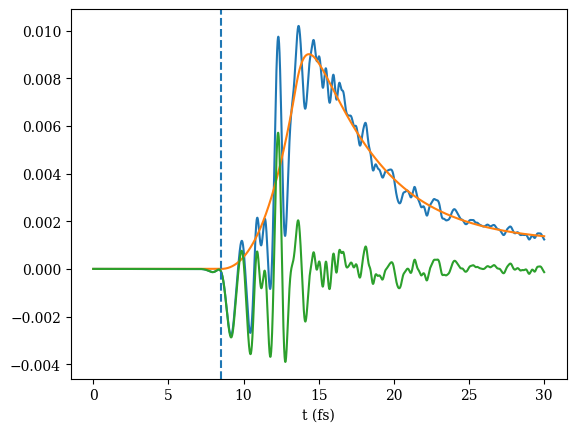

In [24]:
fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
    t=t,
    delta_Jm_x=delta_Jm_x,
    t_array_cut=t_array_cut,
    j_fit=j_fit,
    t_zero_end=8.5,   # твоя физическая “ноль-зона”
    halfmax=0.85
)

plt.figure()
plt.plot(t, delta_Jm_x, label="raw ΔJ")
plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
plt.plot(t, fid, label="FID")
# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# plt.axvline(info["t1"], linestyle="--", label="t1")
# plt.legend()
plt.xlabel("t (fs)")
plt.show()

Mandel's coherence time:  1.7396949597950133
Drude relaxation time:  4.372685961758836


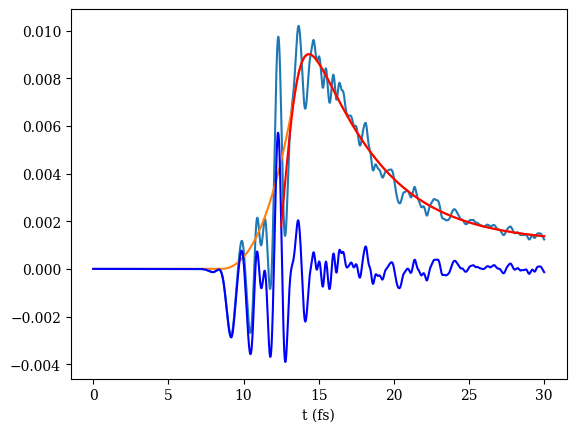

In [42]:
import scipy

fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
    t=t,
    delta_Jm_x=delta_Jm_x,
    t_array_cut=t_array_cut,
    j_fit=j_fit,
    t_zero_end=8.5,   # твоя физическая “ноль-зона”
    halfmax=0.85
)

print("Mandel's coherence time: ",coherence_time(fid, 0.002))
print("Drude relaxation time: ", fit_tau_val)

plt.figure()
plt.plot(t, delta_Jm_x, label="raw ΔJ")
plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
plt.plot(t, fid, label="FID", color='b')
plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# plt.axvline(info["t1"], linestyle="--", label="t1")
# plt.legend()
plt.xlabel("t (fs)")
plt.show()

In [29]:
coherence_time(fid, 0.002)

np.float64(1.6843526308749466)

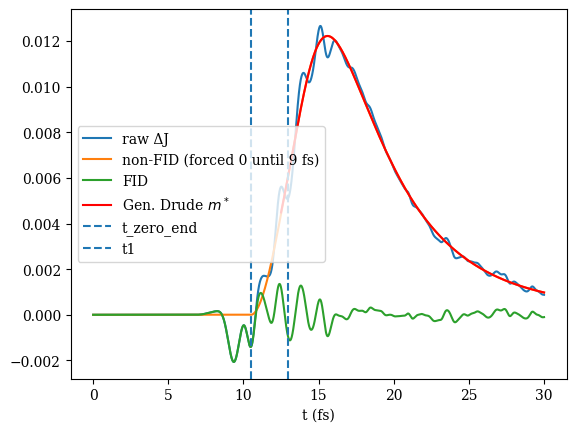

In [57]:
fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
    t=t,
    delta_Jm_x=delta_Jm_x,
    t_array_cut=t_array_cut,
    j_fit=j_fit,
    t_zero_end=10.5,   # твоя физическая “ноль-зона”
    halfmax=0.5
)

plt.figure()
plt.plot(t, delta_Jm_x, label="raw ΔJ")
plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
plt.plot(t, fid, label="FID")
plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
plt.axvline(info["t1"], linestyle="--", label="t1")
plt.legend()
plt.xlabel("t (fs)")
plt.show()

In [25]:
def coherence_time(Y, dt) -> float:
    r"""
    Given a signal Y(t) on an equidistant grid, the function estimates the coherence time.

    The function implements Mandel's coherence time. It calculates the autocorrelation
    function of the given signal, then it calculates the complex envelope of the
    autocorrelation function, and integrates the square of the normalized envelope from
    t=0 to the maximal time. The coherence time is twice the value of the integral.

    Args:
      Y: 1D array that represents the time-dependent signal on a regular grid.
      dt: Time step of the grid.

    Returns:
      the coherence time as a floating-point number.
    """
    ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
    N = len(Y)
    # X = dt * np.arange(-(N - 1), N) # DEBUGGING
    ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
    ACF_envelope /= np.max(ACF_envelope)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    # print("X[i1] =", X[i1]) # DEBUGGING
    return 2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=dt)

## draft v2

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


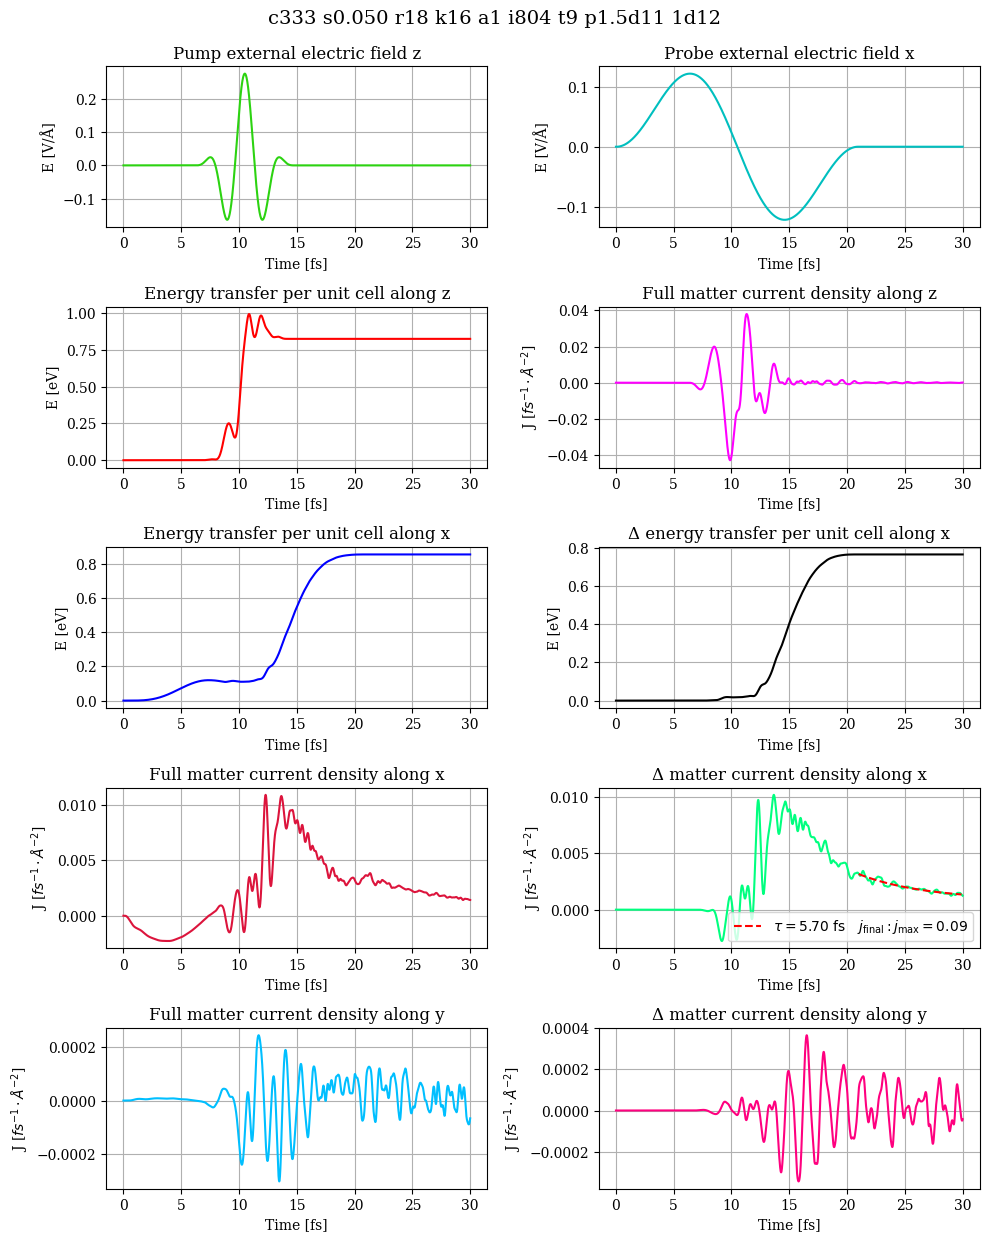

In [7]:

folder = sorted_folders[0]
ax = 'z'
j = 0


# Загрузка данных, пропуская строки с комментариями (начинаются с #)
data_both = pd.read_csv(
    folder + '/both_pulses_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)

data_pump = pd.read_csv(
    folder + '/pump_pulse_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)

data_probe = pd.read_csv(
    folder + '/probe_pulse_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)


# Назначим читаемые имена колонкам
data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']

data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']

data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']


t = data_both['time_fs']


Jm_both_z  =  data_both['Jm_z']

Jm_both_x  =  data_both['Jm_x']
Jm_pump_x  =  data_pump['Jm_x']
Jm_probe_x =  data_probe['Jm_x']

Jm_both_y  =  data_both['Jm_y']
Jm_pump_y  =  data_pump['Jm_y']
Jm_probe_y =  data_probe['Jm_y']


El_f_pump_z = data_both['E_ext_z']
El_f_probe_x = data_both['E_ext_x']


# 1:Time[fs] 2:Ac_ext_x[fs*V/Angstrom] 3:Ac_ext_y[fs*V/Angstrom] 4:Ac_ext_z[fs*V/Angstrom]
#5:E_ext_x[V/Angstrom] 6:E_ext_y[V/Angstrom] 7:E_ext_z[V/Angstrom] 8:Ac_tot_x[fs*V/Angstrom]
# 9:Ac_tot_y[fs*V/Angstrom] 10:Ac_tot_z[fs*V/Angstrom] 11:E_tot_x[V/Angstrom]
# 12:E_tot_y[V/Angstrom] 13:E_tot_z[V/Angstrom]  14:Jm_x[1/fs*Angstrom^2] 15:Jm_y[1/fs*Angstrom^2] 16:Jm_z[1/fs*Angstrom^2]


# Построим графики
plt.figure(figsize=(10, 12.5))

# Общий заголовок для всей фигуры
plt.suptitle(' '.join(re.split('[/_]', folder)), fontsize=14, y=0.99)

# Первый график: внешнее поле по z
plt.subplot(5, 2, 1)
plt.plot(t, El_f_pump_z, label='E_ext_z', color='#2CD311')
plt.xlabel('Time [fs]')
plt.ylabel('E [V/Å]')
plt.title('Pump external electric field z')
plt.grid(True)
#plt.legend()
plt.tight_layout()

# Второй график: внешнее поле по x
plt.subplot(5, 2, 2)
plt.plot(t, El_f_probe_x, label='E_ext_z', color='c')
plt.xlabel('Time [fs]')
plt.ylabel('E [V/Å]')
plt.title('Probe external electric field x')
plt.grid(True)
#plt.legend()
plt.tight_layout()

# Четвертый график: суммарный ток по z
plt.subplot(5, 2, 4)
plt.plot(t, Jm_both_z, color='magenta')
plt.xlabel('Time [fs]')
plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
plt.title('Full matter current density along z')
plt.grid(True)

plt.tight_layout()



product_both_z = El_f_pump_z * Jm_both_z * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_both_z = np.cumsum(product_both_z * dt)

product_both_x = El_f_probe_x * Jm_both_x * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_both_x = np.cumsum(product_both_x * dt)

product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_delta_x = np.cumsum(product_delta_x * dt)



# Построение графика изменения энергии во времени
plt.subplot(5, 2, 3)
# plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
plt.plot(t, -integral_both_z, label='ΔE = E_total - E_initial', color='r')
plt.xlabel('Time [fs]')
plt.ylabel('E [eV]')
plt.title('Energy transfer per unit cell along z')
plt.grid(True)
#plt.legend()
plt.tight_layout()



# Построение графика изменения энергии во времени
plt.subplot(5, 2, 5)
# plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
plt.plot(t, -integral_both_x, label='ΔE = E_total - E_initial', color='blue')
plt.xlabel('Time [fs]')
plt.ylabel('E [eV]')
plt.title('Energy transfer per unit cell along x')
plt.grid(True)
#plt.legend()
plt.tight_layout()


# Построение графика изменения энергии во времени
plt.subplot(5, 2, 6)
# plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
plt.plot(t, -integral_delta_x, label='ΔE = E_total - E_initial', color='black')
plt.xlabel('Time [fs]')
plt.ylabel('E [eV]')
plt.title('Δ energy transfer per unit cell along x')
plt.grid(True)
#plt.legend()
plt.tight_layout()



# Суммарный ток по x
plt.subplot(5, 2, 7)
plt.plot(t, Jm_both_x, color='#DC143C')
plt.xlabel('Time [fs]')
plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
plt.title('Full matter current density along x')
plt.grid(True)
plt.tight_layout()




delta_Jm_x = Jm_both_x - Jm_pump_x - Jm_probe_x


t_array_cut = np.array(t[m0_cut_1:])[::50]
j_exp = np.array(delta_Jm_x[m0_cut_1:])[::50]
# (dummy_t, j0, j_final, tau)
p0 = [0.03, 0.01, 6.65]   # начальные приближения (n, tau)
popt, pcov = curve_fit(drude_current_v1, t_array_cut, j_exp, p0=p0)
j0, j_final, tau= popt
j_fit = drude_current_v1(0, j0, j_final, tau)

ratio = j_final/max(delta_Jm_x)

# Разностный ток по x
plt.subplot(5, 2, 8)
plt.plot(t, (Jm_both_x - Jm_pump_x - Jm_probe_x), color='#00FF7F')
plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau:.2f}\ \mathrm{{fs}} \quad j_{{\rm final}} : j_{{\rm max}} = {ratio:.2f}$", color='r')
plt.xlabel('Time [fs]')
plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
plt.title('Δ matter current density along x')
plt.legend()
plt.grid(True)
plt.tight_layout()




# Суммарный ток по y
plt.subplot(5, 2, 9)
plt.plot(t, Jm_both_y, color='#00BFFF')
plt.xlabel('Time [fs]')
plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
plt.title('Full matter current density along y')
plt.grid(True)
plt.tight_layout()


# Разностный ток по y
plt.subplot(5, 2, 10)
plt.plot(t, (Jm_both_y - Jm_pump_y - Jm_probe_y), color='#FF007F')
plt.xlabel('Time [fs]')
plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
plt.title('Δ matter current density along y')
plt.grid(True)
plt.tight_layout()





# lr_data = pd.read_csv(
#     folder + '/lr_response.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# lr_data.columns = [
#     'Energy',        # 1
#     'Re_sigma_x',    # 2
#     'Re_sigma_y',    # 3
#     'Re_sigma_z',    # 4
#     'Im_sigma_x',    # 5
#     'Im_sigma_y',    # 6
#     'Im_sigma_z',    # 7
#     'Re_eps_x',      # 8
#     'Re_eps_y',      # 9
#     'Re_eps_z',      # 10
#     'Im_eps_x',      # 11
#     'Im_eps_y',      # 12
#     'Im_eps_z',      # 13
# ]


# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 9)
# plt.plot(lr_data['Energy'][100:], lr_data['Im_eps_z'][100:], label='Im(ε)', color='#00BFFF')
# plt.xlabel('E [eV]')
# plt.ylabel('Im(ε)')
# plt.title('Absorption')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()

# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 10)
# plt.plot(lr_data['Energy'][100:], lr_data['Re_eps_z'][100:], label='Re(ε)', color='#FF007F')
# plt.xlabel('E [eV]')
# plt.ylabel('Re(ε)')
# plt.title('Dispersion')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()
# # plt.show()

# plt.savefig("ims/all/" + folder + ".pdf")
# plt.savefig("ims/all/" + str(j)+ '_' + folder + ".png", dpi=200)

dt = np.diff(t, prepend=t[0])

arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
a_start = arr[m0_cut_2-m0_cut_3]
a_fin = arr[-1]




# In[ ]:


c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12
c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976
c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12
c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11
c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12


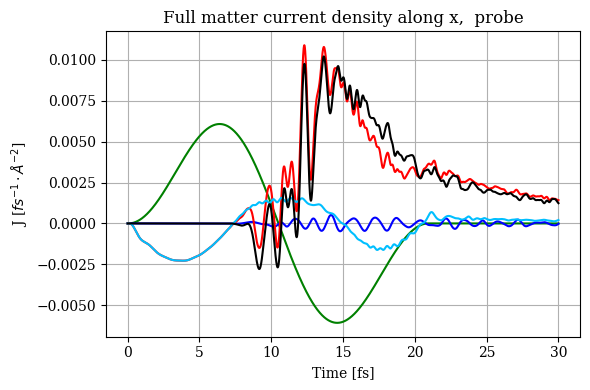

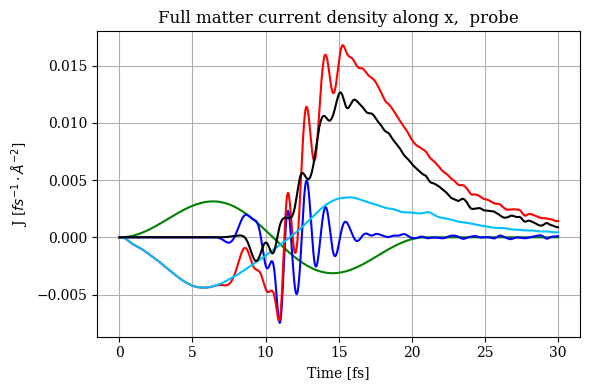

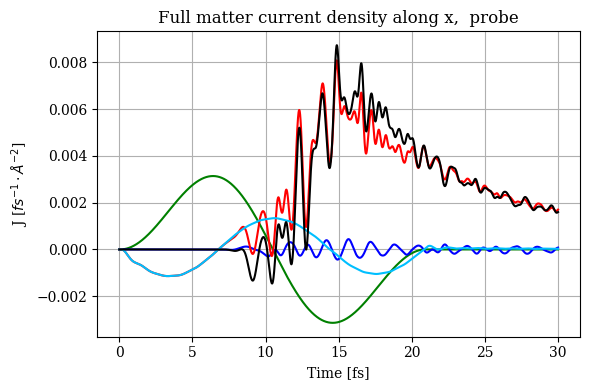

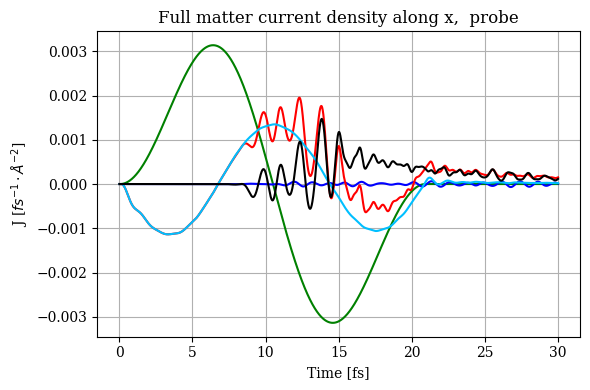

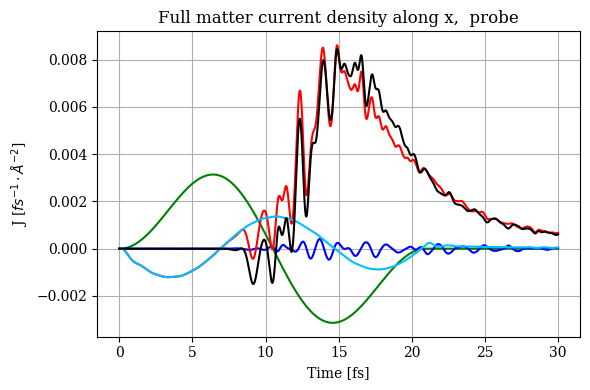

In [40]:

for folder in sorted_folders:

    # folder = sorted_folders[0]
    ax = 'z'
    j = 0


    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    plt.figure(figsize=(6, 4))
    print(folder)
    plt.plot(t, El_f_probe_x/20, color='g')
    plt.plot(t, Jm_pump_x, color='b')
    plt.plot(t, Jm_both_x, color='r')
    plt.plot(t, Jm_probe_x, color='#00BFFF')
    plt.plot(t, Jm_both_x-Jm_pump_x-Jm_probe_x, color='black')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Full matter current density along x,  probe')
    plt.grid(True)
    plt.tight_layout()

c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12
c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976
c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12
c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11
c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12


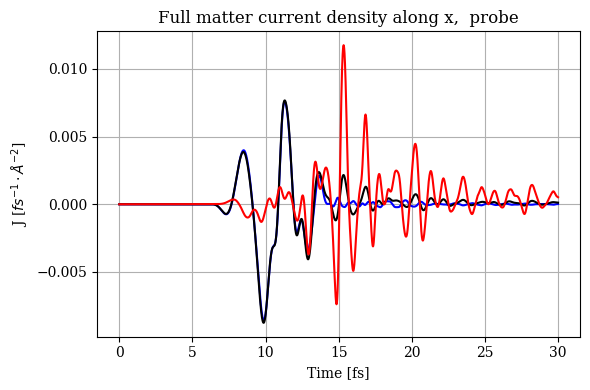

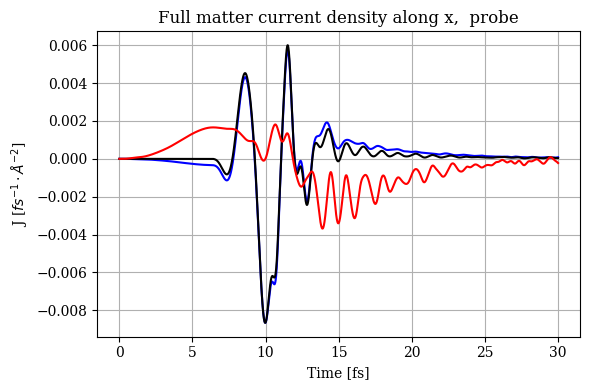

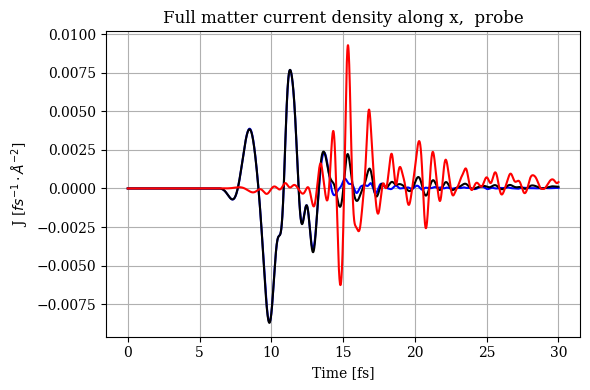

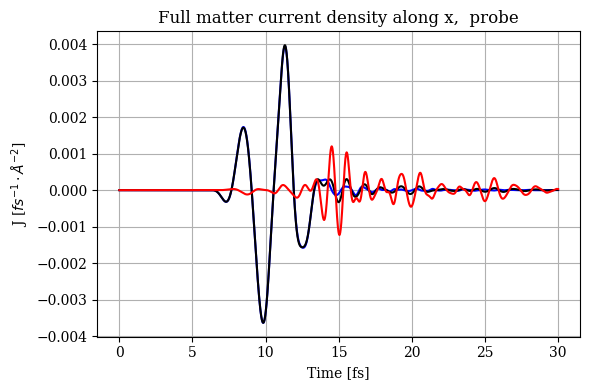

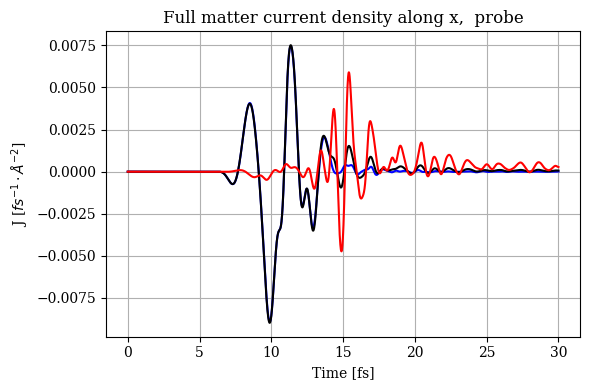

In [57]:

for folder in sorted_folders:

    # folder = sorted_folders[0]
    ax = 'z'
    j = 0


    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    plt.figure(figsize=(6, 4))
    print(folder)
    # plt.plot(t, El_f_probe_x/20, color='g')
    plt.plot(t, Jm_both_z/5, color='b')
    plt.plot(t, Jm_pump_z/5, color='black')
    plt.plot(t, Jm_pump_z-Jm_both_z, color='r')
    # plt.plot(t, Jm_both_y, color='r')
    # plt.plot(t, Jm_probe_y, color='#00BFFF')
    # plt.plot(t, Jm_both_x-Jm_pump_x-Jm_probe_x, color='black')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Full matter current density along x,  probe')
    plt.grid(True)
    plt.tight_layout()

## get data

In [598]:
folder = sorted_folders[4]

# Загрузка данных, пропуская строки с комментариями (начинаются с #)
data_both = pd.read_csv(
    folder + '/both_pulses_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)

data_pump = pd.read_csv(
    folder + '/pump_pulse_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)

data_probe = pd.read_csv(
    folder + '/probe_pulse_rt.data',
    comment='#',
    delim_whitespace=True,
    header=None
)


# Назначим читаемые имена колонкам
data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']

data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']

data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
    'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
    'Jm_x', 'Jm_y', 'Jm_z']


t = data_both['time_fs']


Jm_both_z  =  data_both['Jm_z']
Jm_pump_z  =  data_pump['Jm_z']
Jm_probe_z =  data_probe['Jm_z']

Jm_both_x  =  data_both['Jm_x']
Jm_pump_x  =  data_pump['Jm_x']
Jm_probe_x =  data_probe['Jm_x']

Jm_both_y  =  data_both['Jm_y']
Jm_pump_y  =  data_pump['Jm_y']
Jm_probe_y =  data_probe['Jm_y']


El_f_pump_z = data_both['E_ext_z']
El_f_probe_x = data_both['E_ext_x']



product_both_z = El_f_pump_z * Jm_both_z * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_both_z = np.cumsum(product_both_z * dt)

product_pump_z = El_f_pump_z * Jm_pump_z * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_pump_z = np.cumsum(product_pump_z * dt)

product_probe_z = El_f_pump_z * Jm_probe_z * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_probe_z = np.cumsum(product_probe_z * dt)

product_delta_z = El_f_pump_z * (Jm_both_z - Jm_pump_z - Jm_probe_z) * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_delta_z = np.cumsum(product_delta_z * dt)



product_both_x = El_f_probe_x * Jm_both_x * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_both_x = np.cumsum(product_both_x * dt)

product_pump_x = El_f_probe_x * Jm_pump_x * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_pump_x = np.cumsum(product_pump_x * dt)

product_probe_x = El_f_probe_x * Jm_probe_x * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_probe_x = np.cumsum(product_probe_x * dt)

product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
# Разность по времени
dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
integral_delta_x = np.cumsum(product_delta_x * dt)

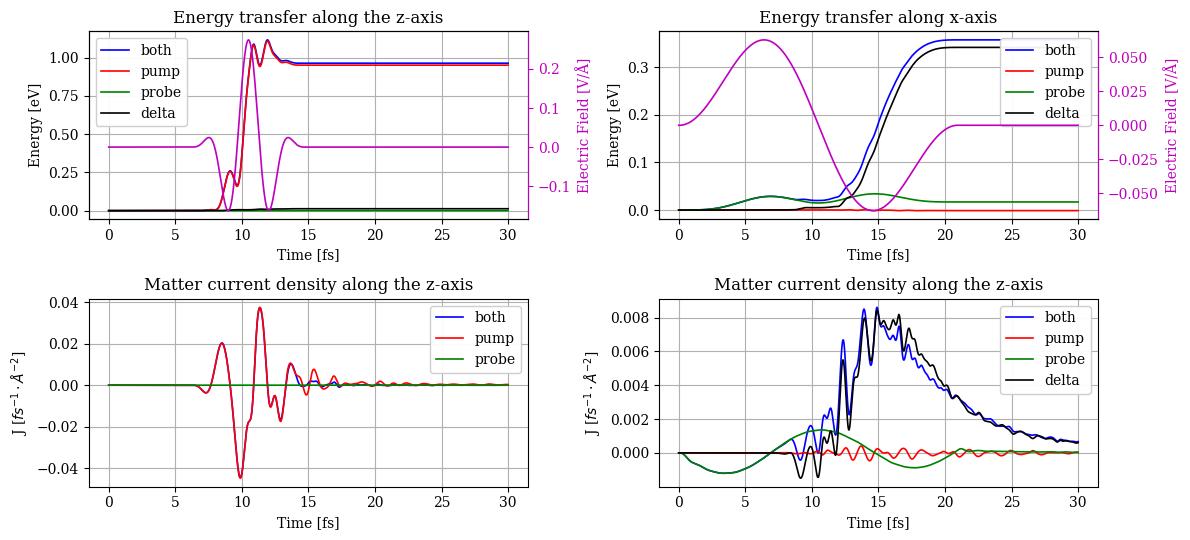

In [599]:
fig, axs = plt.subplots(2, 2, figsize=(12, 5.5))

line_w=1.2
alpha_val=1
color_field = color = mcolors.to_rgba("m", alpha=alpha_val)
framealpha_val=0.95

ax1 = axs[0][1]

ax1.plot(t, -integral_both_x, color='b', label='both', linewidth=line_w)
ax1.plot(t, -integral_pump_x, color='r', label='pump', linewidth=line_w)
ax1.plot(t, -integral_probe_x, color='green', label='probe', linewidth=line_w)
ax1.plot(t, -integral_delta_x, color='black', label='delta', linewidth=line_w)
ax1.set_xlabel('Time [fs]')
ax1.set_ylabel('Energy [eV]')
ax1.set_title('Energy transfer along x-axis')
ax1.legend(loc="upper right", framealpha=framealpha_val)
ax1.grid()
plt.tight_layout()


ax1_right = ax1.twinx()
ax1_right.plot(t, El_f_probe_x, color=color_field, label='probe field', linewidth=1.2)
ax1_right.set_ylabel("Electric Field [V/Å]", color=color_field)
ax1_right.tick_params(axis="y", colors=color_field)
ax1_right.spines["right"].set_color(color_field)
# ax1_right.legend()
plt.tight_layout()



ax2 = axs[0][0]

ax2.plot(t, -integral_both_z, color='b', label='both', linewidth=line_w)
ax2.plot(t, -integral_pump_z, color='r', label='pump', linewidth=line_w)
ax2.plot(t, -integral_probe_z, color='green', label='probe', linewidth=line_w)
ax2.plot(t, -integral_delta_z, color='black', label='delta', linewidth=line_w)
ax2.set_xlabel('Time [fs]')
ax2.set_ylabel('Energy [eV]')
ax2.set_title('Energy transfer along the z-axis')
ax2.legend(framealpha=framealpha_val)
ax2.grid()
plt.tight_layout()


ax2_right = ax2.twinx()
ax2_right.plot(t, El_f_pump_z, color=color_field, label='probe field', linewidth=1.2)
ax2_right.set_ylabel("Electric Field [V/Å]", color=color_field)
ax2_right.tick_params(axis="y", colors=color_field)
ax2_right.spines["right"].set_color(color_field)
# ax1_right.legend()
plt.tight_layout()



ax3 = axs[1][0]

ax3.plot(t, Jm_both_z, color='b', label='both', linewidth=line_w)
ax3.plot(t, Jm_pump_z, color='r', label='pump', linewidth=line_w)
ax3.plot(t, Jm_probe_z, color='green', label='probe', linewidth=line_w)
# ax3.plot(t, -integral_delta_z, color='black', label='delta')
ax3.set_xlabel('Time [fs]')
ax3.set_ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
ax3.set_title('Matter current density along the z-axis')
ax3.legend(framealpha=framealpha_val)
ax3.grid()
plt.tight_layout()


# ax3_right = ax3.twinx()
# ax3_right.plot(t, -El_f_pump_z, color='m', label='probe field')
# ax3_right.set_ylabel("—Electric Field [V/Å]", color='m')
# ax3_right.tick_params(axis="y", colors='m')
# ax3_right.spines["right"].set_color('m')
# # ax1_right.legend()
# plt.tight_layout()



ax4 = axs[1][1]

ax4.plot(t, Jm_both_x, color='b', label='both', linewidth=line_w)
ax4.plot(t, Jm_pump_x, color='r', label='pump', linewidth=line_w)
ax4.plot(t, Jm_probe_x, color='green', label='probe', linewidth=line_w)
ax4.plot(t, (Jm_both_x-Jm_pump_x-Jm_probe_x), color='black', label='delta', linewidth=line_w)
ax4.set_xlabel('Time [fs]')
ax4.set_ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
ax4.set_title('Matter current density along the z-axis')
ax4.legend(framealpha=framealpha_val)
ax4.grid()
plt.tight_layout()

# ax4_right = ax4.twinx()
# ax4_right.plot(t, -El_f_pump_z, color='m', label='probe field')
# ax4_right.set_ylabel("—Electric Field [V/Å]", color='m')
# ax4_right.tick_params(axis="y", colors='m')
# ax4_right.spines["right"].set_color('m')
# # ax1_right.legend()
# plt.tight_layout()



plt.savefig("energies.pdf", bbox_inches="tight")

In [600]:
Jm_both_z  =  data_both['Jm_z']
Jm_pump_z  =  data_pump['Jm_z']
Jm_probe_z =  data_probe['Jm_z']

Jm_both_x  =  data_both['Jm_x']
Jm_pump_x  =  data_pump['Jm_x']
Jm_probe_x =  data_probe['Jm_x']

Jm_both_y  =  data_both['Jm_y']
Jm_pump_y  =  data_pump['Jm_y']
Jm_probe_y =  data_probe['Jm_y']

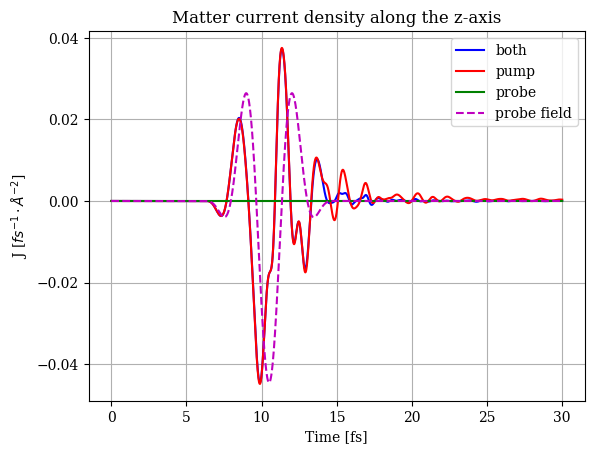

In [601]:
plt.plot(t, Jm_both_z, color='b', label='both')
plt.plot(t, Jm_pump_z, color='r', label='pump')
plt.plot(t, Jm_probe_z, color='green', label='probe')
# plt.plot(t, (Jm_pump_z-Jm_both_z+Jm_probe_z), color='black', label='delta')
plt.plot(t, -1*El_f_pump_z*max(-Jm_both_z)/max(El_f_pump_z), linestyle="--", color='m', label='probe field')
plt.xlabel('Time [fs]')
plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
plt.title('Matter current density along the z-axis')
# plt.ylim(-0.015, 0.015)
plt.legend()
plt.grid()

(-0.02, 0.02)

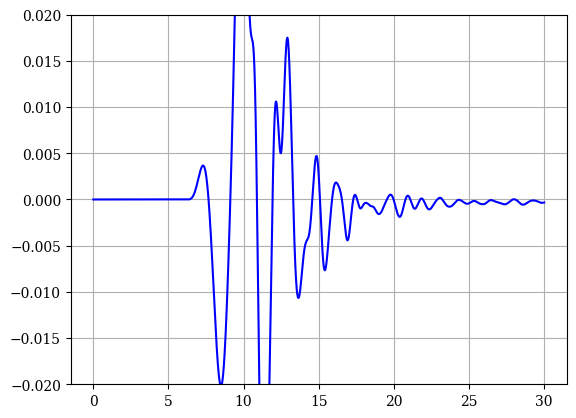

In [603]:
# plt.plot(t, Jm_probe_z, color='green', label='probe')
# plt.plot(t, (Jm_both_z-Jm_pump_z-Jm_probe_z), color='black', label='delta')
plt.plot(t, -Jm_pump_z, color='b')
plt.grid()
plt.ylim(-0.02, 0.02)

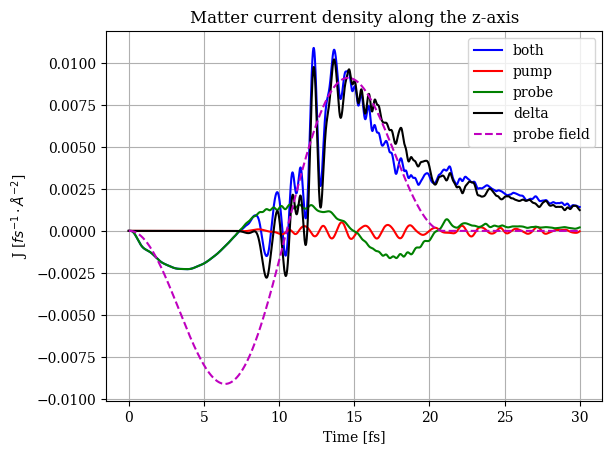

In [579]:
plt.plot(t, Jm_both_x, color='b', label='both')
plt.plot(t, Jm_pump_x, color='r', label='pump')
plt.plot(t, Jm_probe_x, color='green', label='probe')
plt.plot(t, (Jm_both_x-Jm_pump_x-Jm_probe_x), color='black', label='delta')
plt.plot(t, -4*El_f_probe_x*max(-Jm_both_x)/max(El_f_probe_x), linestyle="--", color='m', label='probe field')
plt.xlabel('Time [fs]')
plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
plt.title('Matter current density along the z-axis')
plt.legend()
plt.grid()

In [375]:
# plt.plot(t, -integral_both_x, color='b', label='both')
# plt.plot(t, -integral_pump_x, color='r', label='pump')
# plt.plot(t, -integral_probe_x, color='green', label='probe')
# plt.plot(t, -integral_delta_x, color='black', label='delta')
# plt.plot(t, El_f_probe_x*max(-integral_both_x)/max(El_f_probe_x)/6, linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('Energy [eV]')
# plt.title('Energy transfer per unit cell along x-direction')
# plt.legend()
# plt.grid()

In [376]:
# plt.plot(t, -integral_both_z, color='b', label='both')
# plt.plot(t, -integral_pump_z, color='r', label='pump')
# plt.plot(t, -integral_probe_z, color='green', label='probe')
# plt.plot(t, -integral_both_z+integral_pump_z+integral_probe_z, color='black', label='delta')
# plt.plot(t, El_f_pump_z*max(-integral_both_z)/max(El_f_pump_z)/6, linestyle="--", color='m', label='pump field')
# plt.xlabel('Time [fs]')
# plt.ylabel('Energy [eV]')
# plt.title('Energy transfer per unit cell along z-direction')
# plt.legend()
# plt.grid()

In [166]:
each_num=10

current_energy_array=np.array([ t[::each_num], El_f_pump_z[::each_num], El_f_probe_x[::each_num],
                  Jm_both_z[::each_num], Jm_pump_z[::each_num], Jm_probe_z[::each_num],
                  Jm_both_y[::each_num], Jm_pump_y[::each_num], Jm_probe_y[::each_num],
                  Jm_both_x[::each_num], Jm_pump_x[::each_num], Jm_probe_x[::each_num]
                ])
columns = ["time", "El_f_pump_z", "El_f_probe_x", "Jm_both_z", "Jm_pump_z", "Jm_probe_z", "Jm_both_y", "Jm_pump_y", "Jm_probe_y", 
           "Jm_both_x", "Jm_pump_x", "Jm_probe_x"]
df = pd.DataFrame(current_energy_array.T, columns=columns)


df.to_csv("current_data.csv", index=False)

with open("current_data.csv", "w") as f:
    f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2], Electric field El_f[V/Angstrom], Energy En[eV]\n")
    df.to_csv(f, index=False)

In [167]:
df_read = pd.read_csv("current_data.csv", comment="#")

df_read

,time,El_f_pump_z,El_f_probe_x,Jm_both_z,Jm_pump_z,Jm_probe_z,Jm_both_y,Jm_pump_y,Jm_probe_y,Jm_both_x,Jm_pump_x,Jm_probe_x
0,0.002,0.0,-7.557159e-07,7.691575e-11,7.696432e-11,7.691575e-11,3.915803e-11,3.912546e-11,3.915803e-11,5.106311e-09,-4.200718e-11,5.106311e-09
1,0.022,0.0,-1.292044e-05,5.379631e-13,2.152196e-11,5.379631e-13,4.900295e-11,3.182531e-11,4.900295e-11,5.151949e-07,-6.926585e-11,5.151949e-07
2,0.042,0.0,-1.937559e-05,-1.002600e-10,8.314590e-12,-1.002600e-10,3.701819e-11,-5.756236e-11,3.701819e-11,1.539804e-06,3.428501e-11,1.539804e-06
3,0.062,0.0,-2.012059e-05,-2.393958e-10,-3.215953e-11,-2.393958e-10,1.663043e-10,-5.964760e-12,1.663043e-10,2.671027e-06,3.977624e-12,2.671027e-06
4,0.082,0.0,-1.515535e-05,-3.412354e-10,3.521910e-12,-3.412354e-10,2.329042e-10,-3.012800e-11,2.329042e-10,3.533266e-06,6.452634e-11,3.533266e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,29.902,0.0,0.000000e+00,5.105773e-05,6.488736e-04,-9.183376e-06,-8.814595e-05,-6.174571e-05,1.679852e-05,1.442352e-03,-8.147634e-05,1.778796e-04
1496,29.922,0.0,0.000000e+00,5.993383e-05,6.371406e-04,-8.405439e-06,-8.619631e-05,-5.480611e-05,1.583513e-05,1.433940e-03,-7.150251e-05,1.848109e-04
1497,29.942,0.0,0.000000e+00,6.686776e-05,6.271457e-04,-7.764842e-06,-8.299991e-05,-4.833141e-05,1.437404e-05,1.427385e-03,-6.026848e-05,1.913236e-04
1498,29.962,0.0,0.000000e+00,7.306519e-05,6.186477e-04,-7.272788e-06,-7.853619e-05,-4.239909e-05,1.252857e-05,1.422966e-03,-4.789865e-05,1.972289e-04
